In [14]:
from google import genai
from dotenv import load_dotenv
import os
load_dotenv()
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))
MODEL_NAME = "gemma-4-26b-a4b-it"

In [15]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict , Optional

In [16]:
# ---------- SCHEMA ----------
class NumberGuessSchema(TypedDict):
    hint: str
    current_guess: Optional[int]
    is_correct: Optional[bool]
    attempt_count: int

In [17]:
# ---------- CHECK LOGIC ----------
def is_prime(n: int) -> bool:
    if n < 2:
        return False
    for i in range(2, int(n ** 0.5) + 1):
        if n % i == 0:
            return False
    return True

def meets_condition(n: int) -> bool:
    print('checking for hint condition')
    return is_prime(n) and n > 50

In [18]:
def generate_guess_node(state: NumberGuessSchema) -> dict:
    print('running generate guess node....')
    hint = state['hint']
    prompt = f"Guess a single whole number that satisfies this condition: {hint}. Reply with only the number, nothing else."


    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
    )
    guess_text = response.text.strip()
    try:
        guess = int(guess_text)
    except ValueError:
        guess = -1  # invalid response
    
    return {
        "current_guess": guess,
        "attempt_count": state["attempt_count"] + 1,
    }

In [19]:
def check_guess_node(state: NumberGuessSchema) -> dict:
    print('running check guess node....')
    guess = state['current_guess']
    correct = meets_condition(guess)
    return {
        "is_correct" : correct
    }

In [20]:
def refine_guess_node(state: NumberGuessSchema) -> dict:
    print('running the refine guess node.....')
    hint = state['hint']
    previous_guess = state['current_guess']

    prompt = (
        f"Your previous guess of {previous_guess} did not satisfy this condition: {hint}. "
        f"Guess a different single whole number that satisfies it. Reply with only the number."
    )

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
    )
    guess_text = response.text.strip()
    try:
        guess = int(guess_text)
    except ValueError:
        guess = -1  # invalid response

    return {
            "current_guess": guess,
            "attempt_count": state["attempt_count"] + 1,
        }

In [21]:
MAX_ATTEMPTS = 2

In [22]:
def router_after_check(state: NumberGuessSchema) -> dict:
    print('retrying for refine guess....')
    if state['is_correct']:
        return "correct"
    elif state['attempt_count'] >= MAX_ATTEMPTS:
        return 'give up'
    else:
        return 'retry'

In [23]:
graph = StateGraph(NumberGuessSchema)
graph.add_node('generate guess',generate_guess_node)
graph.add_node('check guess',check_guess_node)
graph.add_node("refine guess", refine_guess_node)

graph.add_edge(START,'generate guess')
graph.add_edge('generate guess','check guess')
graph.add_conditional_edges(
    'check guess',
    router_after_check,
    {
        'correct' : END,
        'give up' : END,
        'retry' :'refine guess'
    }
)
graph.add_edge('refine guess','check guess')

app = graph.compile()

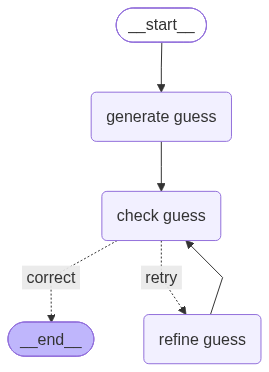

In [24]:
app

In [25]:
result = app.invoke({
    "hint": "a number that is both prime and greater than 50",
    "attempt_count": 0,
})
print(result)

running generate guess node....
running check guess node....
checking for hint condition
retrying for refine guess....
{'hint': 'a number that is both prime and greater than 50', 'current_guess': 53, 'is_correct': True, 'attempt_count': 1}
